# Capstone Assignment - Module I: Predicting some scientific data

**Objective:** Apply machine learning workflows to real scientific  data. You will preprocess data, justify model selection, perform cross-validation, and compare linear models against neural networks.

**Files provided:**
1. `student_data.csv`: Contains the physical features and the target variable (`cfinal`).
2. `evaluation_features.csv`: Contains physical features. The target variable is hidden. You will predict the `cfinal` for these materials and submit them. This will be tested against the expected ones and your score will depend on this.

---
## TEAM MEMBERS
Put here the lastnames, names and emails of your team members. 


---
# Part 1: Data Loading & Preprocessing
1. Load `student_data.csv`.
2. Perform basic Exploratory Data Analysis (EDA). Plot the distribution of `critical_temp`.
3. Check for missing values or extreme anomalies. Be very careful: remove data or if you impute it, justify strongly. 
5. Split this training data into your own local train/test sets (e.g., 80/20) so you can evaluate your models.
6. **Feature Scaling:** Apply appropriate scaling. *Hint: Think carefully about why scaling is absolutely strictly necessary for both Regularized Linear Models and Neural Networks.*

## 1.1) Data loading

In [23]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import functions as f

path = './data/student_data.csv'
df = pd.read_csv(path)
print("the size of the dataset is:", np.size(df))
df.head()
print("amount of columns:", df.columns.size)

the size of the dataset is: 1462860
amount of columns: 86


## 1.2) EDA for cf


--- Statistical Summary of cfinal ---

Skewness: 0.8564850677436356
Kurtosis: -0.5362429567171461


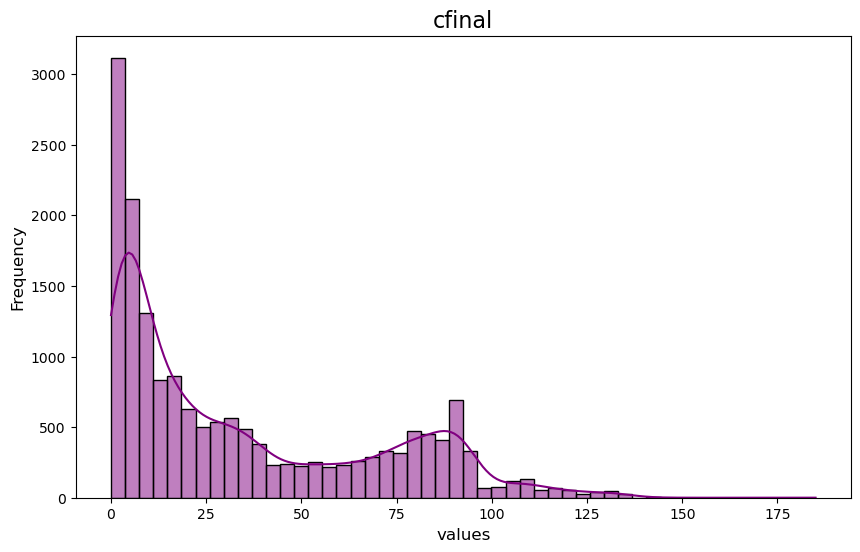

In [24]:
column = 'cfinal'
f.eda_info(df[column],column)

In [25]:

# Definimos nuestra variable objetivo
#target_col = 'cfinal'

# 1. Calculamos el primer (Q1) y tercer cuartil (Q3)
#Q1 = df[target_col].quantile(0.25)
#Q3 = df[target_col].quantile(0.75)

# 2. Calculamos el Rango Intercuartílico (IQR)
#IQR = Q3 - Q1

# 3. Definimos los límites inferior y superior
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR

# 4. Creamos un nuevo DataFrame filtrando las anomalías
# Mantenemos solo las filas donde 'cfinal' esté dentro de los límites
#df_clean = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

# Mostramos los resultados del filtrado
#print(f"Límite inferior aceptado: {lower_bound:.2f}")
#print(f"Límite superior aceptado: {upper_bound:.2f}")
#print(f"Tamaño original del dataset: {len(df)} muestras")
#print(f"Tamaño después de aplicar IQR: {len(df_clean)} muestras")
#print(f"Se removieron {len(df) - len(df_clean)} valores atípicos.")

## 1.3) Missing values  and data Cleaning

amount of null values in the dataset: 1288
columns with null values: Index(['eon', 'amm', 'mwma', 'amg', 'wagm', 'mea', 'maew', 'mra', 'ramw',
       'sam', 'wsam', 'mf', 'mwf', 'fg', 'wgf', 'fe', 'wef', 'rf', 'rfw', 'sf',
       'swf', 'ram', 'rwam', 'gar', 'agwr', 'are', 'wear', 'arr', 'rraw',
       'sra', 'rwas', 'mD', 'mwD', 'Dg', 'wgD', 'De', 'Dew', 'rD', 'rDw', 'Ds',
       'Dws', 'mE', 'mEw', 'gE', 'gEw', 'Ee', 'weE', 'rE', 'Erw', 'sE', 'sEw',
       'mF', 'mwF', 'gF', 'gwF', 'eF', 'wFe', 'rF', 'rwF', 'sF', 'Fws', 'mT',
       'Twm', 'Tg', 'wgT', 'Te', 'eTw', 'rT', 'wrT', 'Ts', 'Tsw', 'Vm', 'mVw',
       'gV', 'gwV', 'eV', 'eVw', 'Vr', 'rwV', 'Vs', 'wVs', 'msqv', 'ril',
       'ped', 'deu', 'cfinal'],
      dtype='object')
null values per column:
eon       14
amm       10
mwma      12
amg       14
wagm      17
          ..
msqv      18
ril       18
ped       12
deu        8
cfinal    17
Length: 86, dtype: int64


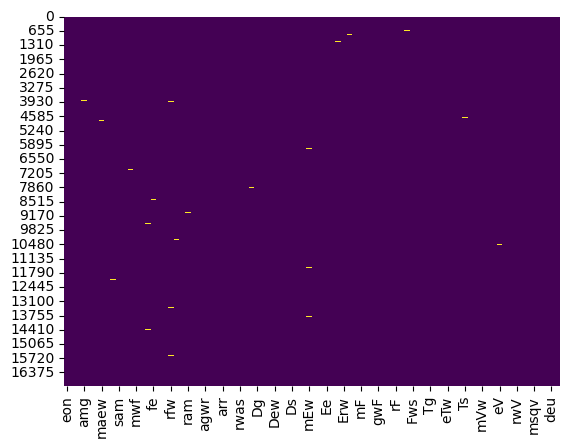

In [26]:

print("amount of null values in the dataset:", df.isna().sum().sum())
print("columns with null values:", df.columns[df.isna().any()])
print("null values per column:")
print(df.isna().sum(axis=0))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.show()

columns:  86
columns:  86


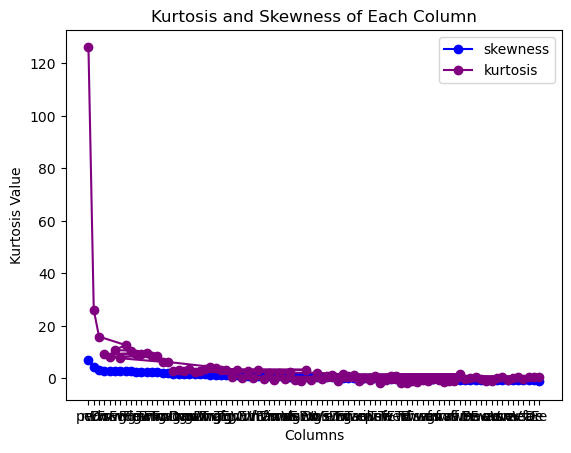

In [27]:
kurtosis = df.kurtosis(axis=0)
skewness = df.skew(axis=0)
sk_sort, ku_sort = f.sort_values(skewness, kurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column', 'kurtosis']
f.plot_values(sk_sort.index, sk_sort.values, sk_text)
f.plot_values(ku_sort.index, ku_sort.values, ku_text, color_used='purple')
#f.total_eda_info(df)


Classifying with kurtosis and skewness 

In [28]:

meso_kt, lepto_kt, platy_kt = f.classify_kurtosis(ku_sort,epsilon=0.1)


Mesokurtic columns:
 5 columns
Leptokurtic columns:
 53 columns
Platykurtic columns:
 28 columns


In [29]:
epsilon = 0.1
print("Meso-Kurtosis Columns skewness:")
left_sk_meso, middle_sk_meso, right_sk_meso = f.classify_skewness(meso_kt, epsilon)
print(" ")
print("Lepto-Kurtosis Columns skewness:")
left_sk_lepto, middle_sk_lepto, right_sk_lepto = f.classify_skewness(lepto_kt, epsilon)
print(" ")
print("Platy-Kurtosis Columns skewness:")
left_sk_platy, middle_sk_platy, right_sk_platy = f.classify_skewness(platy_kt, epsilon)

Meso-Kurtosis Columns skewness:
Left-skewed columns:
 5 columns
Right-skewed columns:
 5 columns
Approximately symmetric columns:
 5 columns
 
Lepto-Kurtosis Columns skewness:
Left-skewed columns:
 53 columns
Right-skewed columns:
 53 columns
Approximately symmetric columns:
 53 columns
 
Platy-Kurtosis Columns skewness:
Left-skewed columns:
 28 columns
Right-skewed columns:
 28 columns
Approximately symmetric columns:
 28 columns


* platy_kurtosis(Mean or min/max) is left skewed wich means we can use the median 
* lepto_kurtosis(Median) is Right skewed wich means we can use the median
* Meso_kurtosis(Mean) is symmetric wich means we can use the mean


In [30]:
print("Meso-Kurtosis Columns:")
print(meso_kt)

Meso-Kurtosis Columns:
             0
eVw   0.065858
eF    0.036338
ril   0.008819
gwV  -0.054869
wear -0.094710


In [31]:
dvalues = df.copy()

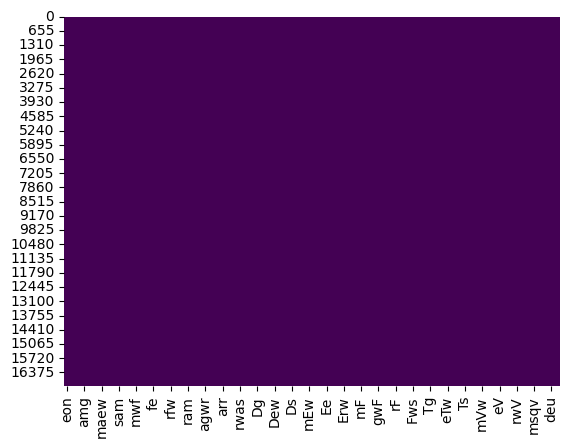

columns:  86
columns:  86
Index(['ped', 'rwF', 'rDw', 'gF', 'mwF', 'wgT', 'gwF', 'Fws', 'deu', 'mF',
       'Tg', 'ramw', 'sF', 'rF', 'mwD', 'mD', 'wrT', 'Twm', 'amg', 'wgD',
       'sEw', 'rE', 'fg', 'mE', 'gE', 'Dg', 'wagm', 'rraw', 'mwma', 'mf',
       'rwV', 'sE', 'Ds', 'amm', 'Dws', 'mT', 'ram', 'rD', 'gar', 'gEw', 'weE',
       'wef', 'Erw', 'mEw', 'De', 'gV', 'Ee', 'Dew', 'fe', 'are', 'mea', 'Vm',
       'eV', 'eVw', 'eF', 'ril', 'gwV', 'wear', 'wFe', 'maew', 'Vs', 'mVw',
       'wVs', 'sam', 'sra', 'wsam', 'cfinal', 'Vr', 'rwam', 'Te', 'mra', 'eon',
       'rwas', 'eTw', 'arr', 'wgf', 'agwr', 'sf', 'rfw', 'rf', 'msqv', 'mwf',
       'swf', 'Ts', 'Tsw', 'rT'],
      dtype='object')


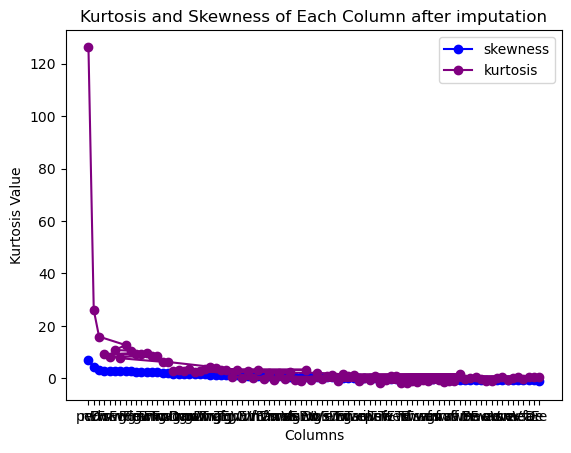

In [32]:

dvalues = f.median_imputation(dvalues, meso_kt.index)
dvalues = f.median_imputation(dvalues, lepto_kt.index)
dvalues = f.mean_imputation(dvalues, platy_kt.index)
dvalues.isna().sum()
sns.heatmap(dvalues.isnull(), cbar=False, cmap='viridis')
plt.show()
dkurtosis = dvalues.kurtosis(axis=0)
dskewness = dvalues.skew(axis=0)
dsk_sort, dku_sort = f.sort_values(dskewness, dkurtosis)
sk_text = ['Columns', 'Skewness Value', 'Skewness of Each Column after imputation', 'skewness']
ku_text = ['Columns', 'Kurtosis Value', 'Kurtosis and Skewness of Each Column after imputation', 'kurtosis']
f.plot_values(dsk_sort.index, dsk_sort.values, sk_text)
f.plot_values(dku_sort.index, dku_sort.values, ku_text, color_used='purple')
print(dku_sort.index)

Ped has a high Kurtosis value, hence we're not using this column for the trainning


--- Statistical Summary of ped ---

Skewness: 6.852915400913597
Kurtosis: 126.38996414859876


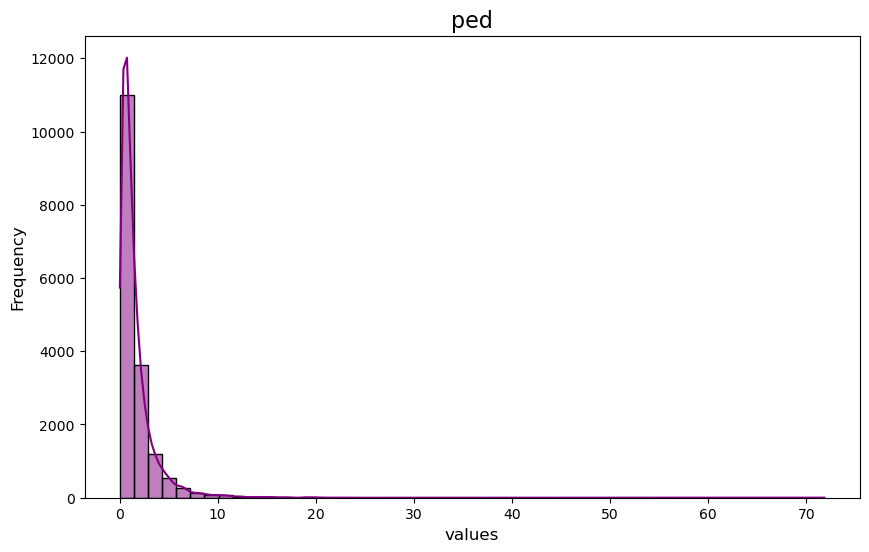

In [33]:
f.eda_info(dvalues['ped'],"ped")

## 1.4)Train test split

In [34]:
#dvalues.drop(columns=['ped'], inplace=True)

In [35]:
#from sklearn.model_selection import train_test_split
#from sklearn.experimental import enable_iterative_imputer
#from sklearn.impute import IterativeImputer
#print("Starting Iterative Imputation (this may take a moment)...")
#X = dvalues.drop('cfinal', axis=1)
#Y = dvalues['cfinal']
#imputer = IterativeImputer(random_state=42, max_iter=10)
#X_imputed_array = imputer.fit_transform(X)
###Convert back to DataFrame
#X_imputed = pd.DataFrame(X_imputed_array, columns=X.columns)
#
#print("Remaining nulls:", X_imputed.isna().sum().sum())
#X_train,X_test,Y_train,Y_test = train_test_split(X_imputed,Y, test_size=0.2, random_state=42)
#print(f"Training set shape: {X_train.shape}")
#print(f"Testing set shape: {X_test.shape}")

Starting Correlation Filtering...
Initial number of features: 85

Dropped 23 features with low correlation (< 0.25):
['amm', 'amg', 'mf', 'fg', 'ram', 'gar', 'Ds', 'Dws', 'mE', 'mEw', 'gEw', 'weE', 'Erw', 'rF', 'sF', 'Fws', 'Te', 'eTw', 'Vr', 'Vs', 'msqv', 'ril', 'ped']

After correlation filtering:
Features remaining: 62
Training set shape: (13608, 62)
Testing set shape:  (3402, 62)


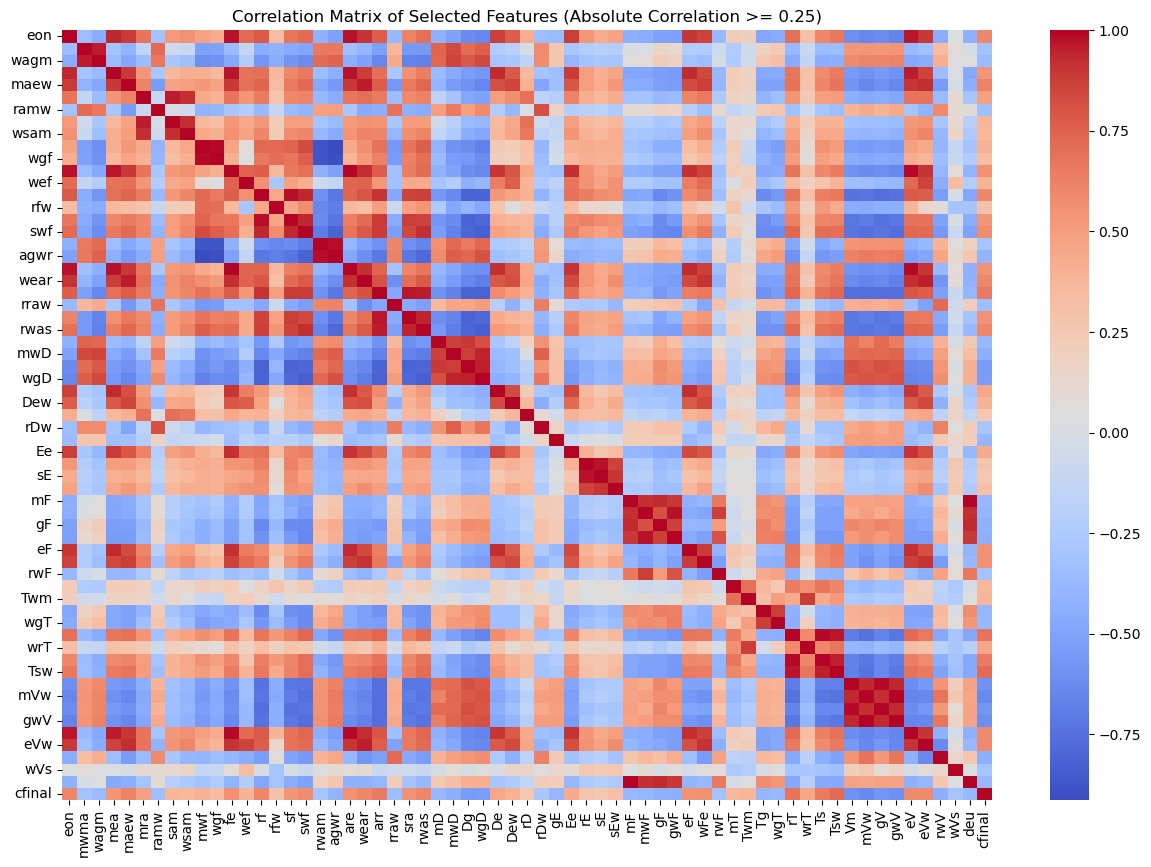

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Separate features and target initially
X = dvalues.drop('cfinal', axis=1)
Y = dvalues['cfinal']

# 2. Split into training and testing sets FIRST (Prevents Data Leakage)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Starting Correlation Filtering...")
print("Initial number of features:", X_train.shape[1])

# 3. Calculate correlation ONLY on the training data
# We temporarily combine X_train and Y_train to see their relationship
train_combined = X_train.copy()
train_combined['cfinal'] = Y_train
corr_matrix_full = train_combined.corr()

# 4. Extract only the correlation values with the target 'cfinal'
# We drop 'cfinal' itself so we only look at feature-to-target correlations
target_corr = corr_matrix_full['cfinal'].drop('cfinal')

# 5. Filter features based on the ABSOLUTE value of correlation
threshold = 0.25
selected_features = target_corr[abs(target_corr) >= threshold].index
dropped_features = target_corr[abs(target_corr) < threshold].index

print(f"\nDropped {len(dropped_features)} features with low correlation (< {threshold}):")
print(list(dropped_features))

# 6. Apply the filter to both Train and Test sets
X_train_filtered = X_train[selected_features]
X_test_filtered = X_test[selected_features]

print(f"\nAfter correlation filtering:")
print(f"Features remaining: {X_train_filtered.shape[1]}")
print(f"Training set shape: {X_train_filtered.shape}")
print(f"Testing set shape:  {X_test_filtered.shape}")

# 7. Visualize the updated correlations (only for kept features + target)
plt.figure(figsize=(15, 10))
# Filter the original full matrix to only show chosen features and target
keep_cols = list(selected_features) + ['cfinal']
sns.heatmap(corr_matrix_full.loc[keep_cols, keep_cols], 
            annot=False, 
            cmap='coolwarm', 
            fmt=".2f")
plt.title(f'Correlation Matrix of Selected Features (Absolute Correlation >= {threshold})')
plt.show()

## 1.5) Scaling the features

In [52]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Part 2: Conceptual Questions & Model Selection

**Answer the following questions below:**
1. Why is this specific problem framed as a **Regression** task?
2. If a colleague suggested using **Logistic Regression** for this task, how would you explain to them mathematically and conceptually why that is the wrong choice?

Because we are trying to predict the behaviour of cfinal, wich we can consider as a continuous variable that depends on a linear combination of the other features.
Wich means that a linear regression model is appropriate for this task, as it can capture the linear relationships between the features and the target variable.
Furthermore cfinal is a normal distribution with kurtosis and skewness values close to 0, which indicates that it is a good candidate for linear regression.
2.Logistic regression is not suitable for this task because it is designed for classification problems, where the target variable is categorical. In contrast, linear regression is specifically designed for regression problems, where the target variable is continuous, making it the appropriate choice for predicting the final grade of the students.
In the case of the linear regression we have a continous set of values as.
\begin{equation*}
\hat{y} = \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n}
\end{equation*}
 And in Logistic regression we use the sigmoid function wich maps the values between 0 and 1. 
\begin{equation*}
P(y=1|X) = \frac{1}{1+ e^{-( \beta_{0} + \beta_{1}x_{1} +...+\beta_{n}x_{n})}}
\end{equation*}

* When z is large and positive $e^{-z}$ approaches 0, so $\sigma{(z)}$ approaches 1.
* When z is large and negative  $e^{-z}$ becomes very large, so $\sigma{(z)}$ approaches 0.
* When z = 0, $e^0 = 1$, so $\sigma{(z)} = 0.5 $


# Part 3: Linear Regression & Regularization
1. **Unregularized Linear Regression:** Train a standard Ordinary Least Squares (OLS) Linear Regression model. Record its performance (RMSE, MAE, and $R^2$) on your local test set.
2. Analyze the fullfilment of the linear regression model assumptions. 
3. **Regularization (Ridge & Lasso):** 
   * Train a Ridge (L2) and a Lasso (L1) regression model. 
   * Use $k$-fold cross-validation to find the optimal regularization hyperparameters ($\alpha$).
4. **Reflection:** Print the top 5 largest coefficients from your unregularized model and your Ridge model. How drastically did they change? 
5. **Feature Selection:** Did your Lasso model drop any features (set their coefficients to exactly zero)? Look specifically at `lattice_refraction_index` and `mean_quantum_spin_variance`. What does their coefficient in the Lasso model tell you about their physical relevance to superconductivity?
6. **Include your best linear model weights in the submission using `joblib`**

In [53]:
import numpy as np
import pandas as pd
import functions as f
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import joblib
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
print("--- 1. OLS Linear Regression ---")
u_model = LinearRegression()
u_model.fit(X_train_scaled, Y_train)
u_preds = u_model.predict(X_test_scaled)

# Cálculo de Métricas solicitadas
ols_rmse, ols_mae, ols_r2 = f.evaluate_model(u_model, X_test_scaled, Y_test, "Unregularized Linear Regression")



--- 1. OLS Linear Regression ---
Unregularized Linear Regression RMSE: 17.774
Unregularized Linear Regression MAE:  13.579
Unregularized Linear Regression R^2:  0.731



Checking for Linearity (Visual Check)...


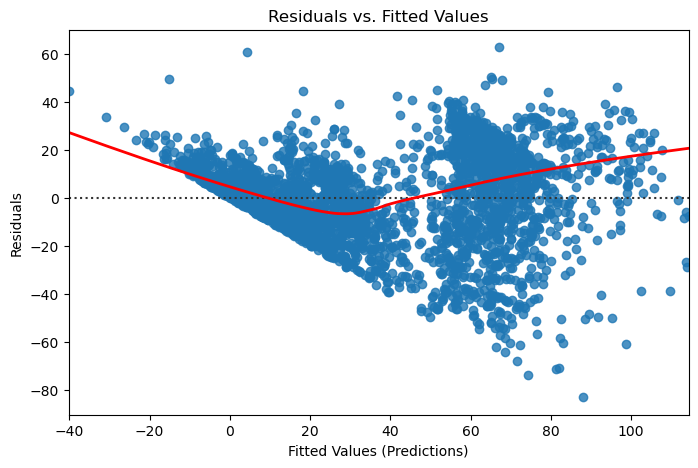

Checking for Independence of Residuals (Durbin-Watson Test)...
Durbin-Watson statistic: 1.95
Result: No significant autocorrelation (Good).


Checking for Homoscedasticity (Breusch-Pagan Test)...
Breusch-Pagan Test p-value: 0.0000
Result: Evidence of heteroscedasticity found (Bad).


Checking for Normality of Residuals (Q-Q Plot and Jarque-Bera)...


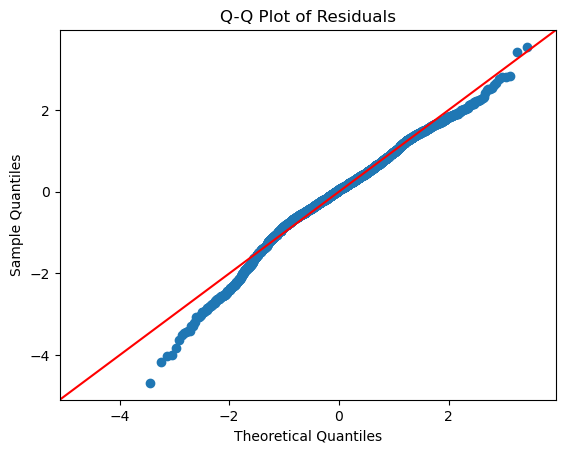

Jarque-Bera test probability (p-value): 0.0000
Result: Residuals may not be normally distributed (Bad).


Checking for Multicollinearity (VIF)...
    feature         VIF
0         0   65.767965
1         1  295.020559
2         2  602.804546
3         3  324.014942
4         4  633.419192
..      ...         ...
80       80   16.261200
81       81    1.022753
82       82    1.022385
83       83    1.016694
84       84  537.134778

[85 rows x 2 columns]

Result: Potential multicollinearity detected (Bad).




In [54]:
f.tests_check(u_model, X_test_scaled, Y_test)

### Ridge and Lasso

In [55]:

# Definimos una grilla logarítmica de alphas para buscar el óptimo
alphas_grid = np.logspace(-4, 4, 100)
# RidgeCV y LassoCV hacen la validación cruzada k-fold internamente
r_model = RidgeCV(alphas=alphas_grid, cv=5)
r_model.fit(X_train_scaled, Y_train)

l_model = LassoCV(alphas=alphas_grid, cv=5, max_iter=10000) # max_iter alto para convergencia
l_model.fit(X_train_scaled, Y_train)

print(f"Optimal Ridge alpha: {r_model.alpha_:.4f}")
print(f"Optimal Lasso alpha: {l_model.alpha_:.4f}\n")

Optimal Ridge alpha: 3.3516
Optimal Lasso alpha: 0.0024



In [56]:
r_mse, r_mae, r_r2 = f.evaluate_model(r_model, X_test_scaled, Y_test, "Ridge Regression")
l_mse, l_mae, l_r2 = f.evaluate_model(l_model, X_test_scaled, Y_test, "Lasso Regression")

Ridge Regression RMSE: 17.753
Ridge Regression MAE:  13.580
Ridge Regression R^2:  0.731

Lasso Regression RMSE: 17.764
Lasso Regression MAE:  13.575
Lasso Regression R^2:  0.731



In [57]:
#f.check_regularized_residuals(r_model, X_test_scaled, Y_test, "Ridge Regression")
#f.check_regularized_residuals(l_model, X_test_scaled, Y_test, "Lasso Regression")

Top 5 Coeficientes

In [58]:

print("--- 4. Reflection: Coefficient Comparison ---")
# Usamos el atributo .coef_ de los modelos
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns) # Convertir a DataFrame para obtener nombres de columnas
features = X_train_scaled_df.columns # Asegúrate de que X_train_scaled sea un DataFrame, si es numpy usa tus feature_names

# Unir coeficientes en un DataFrame para compararlos
coef_df = pd.DataFrame({
    'Feature': features,
    'OLS_Coef': u_model.coef_,
    'Ridge_Coef': r_model.coef_,
    'Lasso_Coef': l_model.coef_
})


coef_df['OLS_abs'] = coef_df['OLS_Coef'].abs()
coef_df['ridge_abs'] = coef_df['Ridge_Coef'].abs()
coef_df['lasso_abs'] = coef_df['Lasso_Coef'].abs()
top_5_ols = coef_df.sort_values(by='OLS_abs', ascending=False).head(5)
top_5_ridge = coef_df.sort_values(by='ridge_abs', ascending=False).head(5)
top_5_lasso = coef_df.sort_values(by='lasso_abs', ascending=False).head(5)

print("Top 5 largest coefficients (Unregularized OLS):")
print(top_5_ols[['Feature', 'OLS_Coef']])

print("Top 5 largest coefficients (Ridge):")
print(top_5_ridge[['Feature', 'Ridge_Coef']])

print("Top 5 largest coefficients (Lasso):")
print(top_5_lasso[['Feature', 'Lasso_Coef']])



--- 4. Reflection: Coefficient Comparison ---
Top 5 largest coefficients (Unregularized OLS):
   Feature   OLS_Coef
22    rwam  33.352559
24    agwr -28.451116
49      sE  22.008258
62     Twm  21.644234
29     sra -19.081308
Top 5 largest coefficients (Ridge):
   Feature  Ridge_Coef
22    rwam   27.518279
24    agwr  -21.549353
49      sE   21.400404
62     Twm   20.893473
29     sra  -18.980802
Top 5 largest coefficients (Lasso):
   Feature  Lasso_Coef
22    rwam   31.612582
24    agwr  -26.527959
49      sE   21.747868
62     Twm   21.167284
29     sra  -18.552602


In [59]:
print("--- 5. Feature Selection (Lasso) ---")
dropped_features = coef_df[coef_df['Lasso_Coef'] == 0]['Feature'].tolist()
print(f"Lasso dropped {len(dropped_features)} features.")
for feature in ['ril', 'msqv']:
    if feature in coef_df['Feature'].values:
        val = coef_df.loc[coef_df['Feature'] == feature, 'Lasso_Coef'].values[0]
        if val == 0:
            print(f"-> {feature} fue eliminada (coef = 0). Físicamente, esto sugiere que no tiene poder predictivo o es redundante para predecir la temperatura crítica.")
        else:
            print(f"-> {feature} se mantuvo con un coeficiente de {val:.4f}.")

# ==========================================
# 6. Save Best Linear Model
# ==========================================
# Asumiendo que el mejor fue Ridge basándonos en tu prueba preliminar
best_model = r_model
joblib.dump(best_model, 'best_linear_model.pkl')
print("\nModelo guardado exitosamente como 'best_linear_model.pkl'")
#model testing


--- 5. Feature Selection (Lasso) ---
Lasso dropped 2 features.
-> ril se mantuvo con un coeficiente de 0.0841.
-> msqv se mantuvo con un coeficiente de -0.0988.

Modelo guardado exitosamente como 'best_linear_model.pkl'


# Part 4: Neural Networks
1. **Build a Neural Network:** Implement a feedforward Neural Network (Multi-Layer Perceptron) using `sklearn`, `PyTorch`, or `Keras`.
2. **Cross-Validation/Tuning:** Experiment with the architecture (number of hidden layers, neurons) and learning rate. Use a validation set to prevent overfitting (Early Stopping is highly recommended).
3. **Evaluation:** Evaluate your best Neural Network on your local test set using the same metrics as the linear models (RMSE, MAE, $R^2$). 
4. **Reflection:** Plot the residuals (predicted vs. true values) for both your best Linear model and your Neural Network. In what range does the linear model struggle the most compared to the NN?
5. **Include your best nn weights in the submission using `joblib`**. Describe the arquitecture.

# Part 5: Final Analysis and Exporting Predictions

**Final Analysis:**
Which model performed the best on your local test set? If a physicist asked you *which features* are most important for discovering a new material with this data, which model would you show them and why? Explain the trade-off between interpretability and performance in this context.

**Generate Final Predictions:**
Use your **best overall model** to predict the critical temperatures for the materials in `evaluation_features.csv`. Export your predictions to a CSV file named `my_predictions.csv`. It is just one column. Call it `predicted_cfinal`. 

# Bonus
If you first perform PCA, can you accomplish any dimensionality reduction? are your predictions better? analyze and support your claims.  